# Recurrent Neural Networks
https://github.com/saqemlas/deep-learning-specialization/blob/main/5_SequenceModels/week_1/Assignment/Building_a_Recurrent_Neural_Network_Step_by_Step.ipynb

In [1]:
import matplotlib.pyplot as plt
from keras.datasets import imdb
from keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense

2026-04-13 16:30:30.903632: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-13 16:30:31.412445: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-13 16:30:33.111064: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
max_features = 10000 # Number of words to consider as features
maxlen = 500 # Cuts off texts after this number of words (among the max_features most common words)
batch_size = 32 

In [3]:
start_char = 1
oov_char = 2 # Out of vocabulary character
index_from = 3 # Index actual words with this index and higher

In [4]:
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features, maxlen=maxlen)#, start_char=start_char, oov_char=oov_char, index_from=index_from)
# Load training and test data, keeping only the top max_features most frequent words, and cutting off texts after maxlen words (among the max_features most common words)

In [5]:
input_train[3:]

array([list([1, 249, 1323, 7, 61, 113, 10, 10, 13, 1637, 14, 20, 56, 33, 2401, 18, 457, 88, 13, 2626, 1400, 45, 3171, 13, 70, 79, 49, 706, 919, 13, 16, 355, 340, 355, 1696, 96, 143, 4, 22, 32, 289, 7, 61, 369, 71, 2359, 5, 13, 16, 131, 2073, 249, 114, 249, 229, 249, 20, 13, 28, 126, 110, 13, 473, 8, 569, 61, 419, 56, 429, 6, 1513, 18, 35, 534, 95, 474, 570, 5, 25, 124, 138, 88, 12, 421, 1543, 52, 725, 6397, 61, 419, 11, 13, 1571, 15, 1543, 20, 11, 4, 2, 5, 296, 12, 3524, 5, 15, 421, 128, 74, 233, 334, 207, 126, 224, 12, 562, 298, 2167, 1272, 7, 2601, 5, 516, 988, 43, 8, 79, 120, 15, 595, 13, 784, 25, 3171, 18, 165, 170, 143, 19, 14, 5, 7224, 6, 226, 251, 7, 61, 113]),
       list([1, 778, 128, 74, 12, 630, 163, 15, 4, 1766, 7982, 1051, 2, 32, 85, 156, 45, 40, 148, 139, 121, 664, 665, 10, 10, 1361, 173, 4, 749, 2, 16, 3804, 8, 4, 226, 65, 12, 43, 127, 24, 2, 10, 10]),
       list([1, 6740, 365, 1234, 5, 1156, 354, 11, 14, 5327, 6638, 7, 1016, 2, 5940, 356, 44, 4, 1349, 500, 746, 5, 200,

In [6]:
len(input_train[3])

147

In [11]:
input_train.max()

[1,
 9995,
 2,
 7,
 2208,
 7335,
 3135,
 4173,
 3783,
 509,
 1683,
 4702,
 2,
 2,
 6,
 201,
 7,
 6415,
 687,
 2,
 2,
 7,
 6387,
 548,
 139,
 7583,
 295,
 34,
 4485,
 5302,
 2,
 2,
 2,
 7,
 2,
 2,
 146,
 24,
 1017,
 2282,
 133,
 21,
 4,
 1591,
 3113,
 786,
 2,
 16,
 125,
 4,
 2,
 9790,
 2039,
 137,
 267,
 2,
 5,
 2,
 120,
 2024,
 980,
 2,
 1248,
 5666,
 727,
 1405,
 6879,
 1060,
 6442,
 18,
 2,
 1461,
 2,
 1883,
 445,
 109,
 5369,
 3696,
 33,
 236,
 786,
 5580,
 7994,
 8,
 2,
 2,
 103,
 2,
 98,
 11,
 2,
 1461,
 24,
 66,
 351,
 1461,
 165,
 116,
 17,
 2545,
 18,
 6717,
 8694,
 5514,
 980,
 2545,
 165,
 734,
 18,
 2311,
 52,
 84,
 157,
 18,
 7232,
 11,
 661,
 8,
 607,
 3531,
 223,
 1066,
 445,
 9236,
 996,
 8,
 2898,
 4931,
 8,
 5526,
 8316,
 7880,
 154,
 378,
 459,
 18,
 6942,
 632,
 5,
 79,
 2024,
 18,
 68,
 4918,
 813,
 2456,
 2,
 17,
 840,
 4807,
 3854,
 23,
 136,
 159,
 5770,
 852,
 1698,
 632,
 7708,
 7993,
 1003,
 1372,
 5747,
 2,
 7,
 5840,
 5408,
 11,
 7200,
 120,
 4682,
 7,
 2,


In [8]:
word_index = imdb.get_word_index()
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [13]:
# Reverse the word index to obtain a dict mapping indices to words
# And add 'index_from' to indices to sync with 'x_train'
inverted_word_index = dict((i + index_from, word) for (word, i) in word_index.items())

# Update inverted_word_index to include 'start_char and oov_char
inverted_word_index[start_char] = "[START]"
inverted_word_index[oov_char] = "[OOV]"
# Decode the first sequence in the dataset
decoded_sequence = ' '.join(inverted_word_index[i] for i in input_train[3])
decoded_sequence

"[START] worst mistake of my life br br i picked this movie up at target for 5 because i figured hey it's sandler i can get some cheap laughs i was wrong completely wrong mid way through the film all three of my friends were asleep and i was still suffering worst plot worst script worst movie i have ever seen i wanted to hit my head up against a wall for an hour then i'd stop and you know why because it felt damn good upon bashing my head in i stuck that damn movie in the [OOV] and watched it burn and that felt better than anything else i've ever done it took american psycho army of darkness and kill bill just to get over that crap i hate you sandler for actually going through with this and ruining a whole day of my life"

In [14]:
input_train = pad_sequences(input_train, maxlen=maxlen)
input_test = pad_sequences(input_test, maxlen=maxlen)
# Use beforehand selected maximum length to the consequent data of the training and test sets. Sequences longer than this will be truncated, and sequences shorter will be padded with zeros at the beginning.

In [15]:
input_train[3:]

array([[   0,    0,    0, ...,    7,   61,  113],
       [   0,    0,    0, ...,    2,   10,   10],
       [   0,    0,    0, ...,   55,   52, 1901],
       ...,
       [   0,    0,    0, ...,    4, 3586,    2],
       [   0,    0,    0, ...,   12,    9,   23],
       [   0,    0,    0, ...,  204,  131,    9]], dtype=int32)

In [16]:
len(input_train[0])

500

In [17]:
input_train[3]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [20]:
model = Sequential()
# Create empty Sequential model

# Add an Embedding layer for words conversion with the following arguments:
# - max_features: the size of the vocabulary, i.e. maximum integer index + 1
# - 32: the dimension of the dense embedding

# Add Empbedding layer for words conversion 
model.add(Embedding(max_features, 32))
# Parameter: number of words to consider as features (vocabulary size), dimension of the dense embedding (size of the embedding vector for each word)



# Add SimpleRNN layer with 32 units
model.add(SimpleRNN(32))
# Parameter: number of units (size of the hidden state)



# Add a Dense classifier on top with a single unit and sigmoid activation
model.add(Dense(1, activation='sigmoid'))
# Parameters: number of units (output dimension), activation function (sigmoid for binary classification)

2026-04-13 17:52:29.947437: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [25]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.build(input_shape=(None, maxlen))

In [26]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# len(model.layers[0].weights[0][0])
model.layers[0].weights[0][0] # one vector of length 32 per word -> this is learnt

<tf.Tensor: shape=(32,), dtype=float32, numpy=
array([-0.08905721, -0.03095737,  0.02284161, -0.016621  ,  0.01421476,
       -0.08176163, -0.11072642,  0.05738411,  0.14413582, -0.00292183,
        0.08610287, -0.02245837,  0.08756909, -0.06970807,  0.08475409,
       -0.03214827, -0.03446494, -0.02872282, -0.06117319, -0.05312029,
       -0.01245843,  0.00141811, -0.03240317, -0.06145927,  0.05273036,
       -0.02887585,  0.04989187, -0.04462791,  0.09456013,  0.02831326,
        0.01750704,  0.09806771], dtype=float32)>

In [ ]:
history = model.fit(input_train, y_train, epochs=5, batch_size=128, validation_split=0.3)
# Launch model learning for train data and 5 epochs, with a batch size of 128, and using 30% of the data for validation. Store training history in 'history' variable.

Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - acc: 0.5927 - loss: 0.6574 - val_acc: 0.6623 - val_loss: 0.6017
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step - acc: 0.7970 - loss: 0.4496 - val_acc: 0.7597 - val_loss: 0.5051
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - acc: 0.8640 - loss: 0.3313 - val_acc: 0.7942 - val_loss: 0.4796
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - acc: 0.8952 - loss: 0.2651 - val_acc: 0.7535 - val_loss: 0.5879
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - acc: 0.9203 - loss: 0.2107 - val_acc: 0.8338 - val_loss: 0.4175


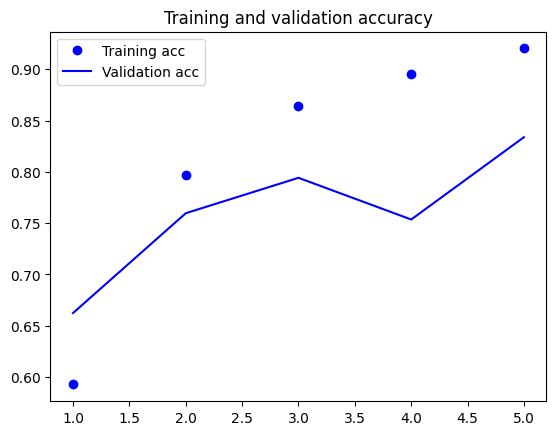

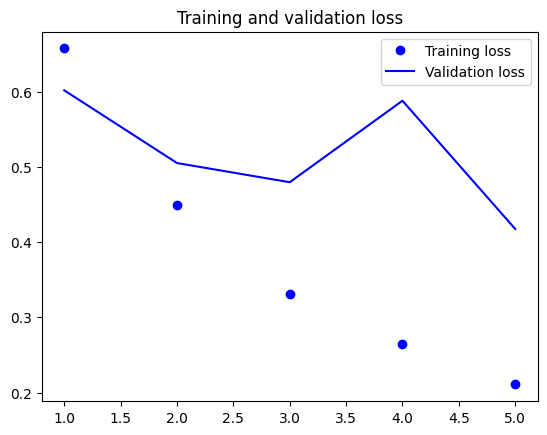

In [31]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

# Embedding
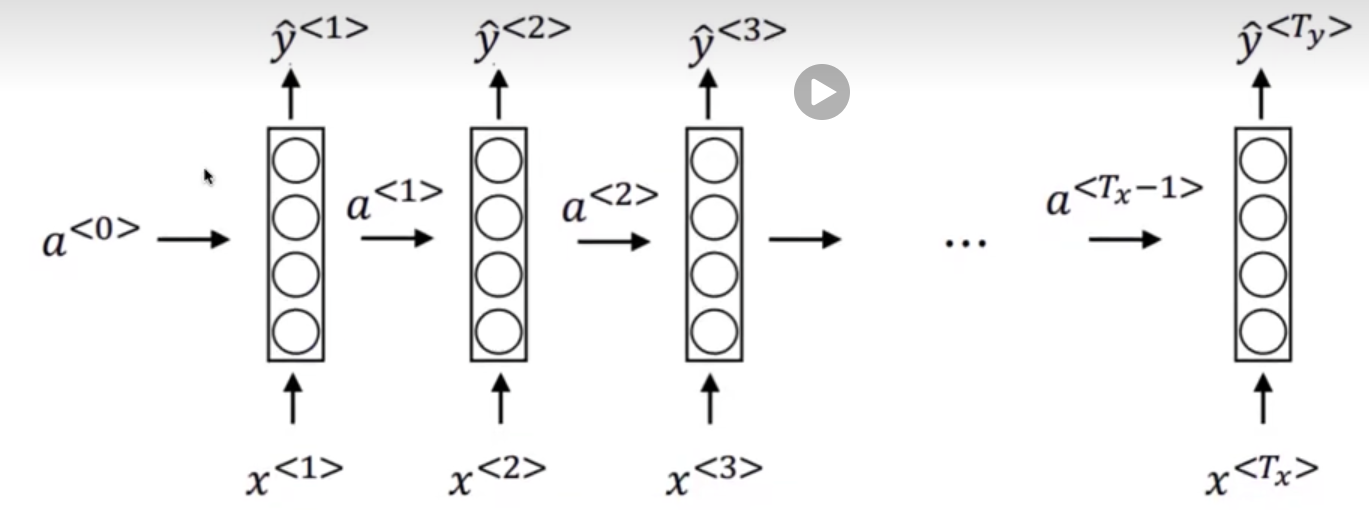